### Introdction to PyTorch

In [1]:
import torch
torch.__version__

ModuleNotFoundError: No module named 'torch'

In [2]:
import torch
torch.cuda.is_available()

False

In [5]:
import torch
torch.cuda.is_available()

False

In [6]:
print(torch.backends.mps.is_available())

True


In [7]:
%load_ext watermark
%watermark -a 'Sebastian Raschka' -v -p torch

Author: Sebastian Raschka

Python implementation: CPython
Python version       : 3.10.13
IPython version      : 8.25.0

torch: 2.4.0



In [8]:
import torch

tensor0d = torch.tensor(1)

tensor1d = torch.tensor([1, 2, 3])

tensor2d = torch.tensor([[1, 2], 
                         [3, 4]])

tensor3d = torch.tensor([[[1, 2], [3, 4]], 
                         [[5, 6], [7, 8]]])

print(tensor0d)

tensor(1)


In [30]:
print(tensor1d)

tensor([1, 2, 3])


In [31]:
print(tensor2d)

tensor([[1, 2],
        [3, 4]])


In [32]:
a = torch.tensor([1, 2, 3])
print(a.dtype)

torch.int64


In [38]:
data = torch.tensor([[1, 2, 3], [4,5,6]]) 
data

tensor([[1, 2, 3],
        [4, 5, 6]])

In [39]:
data.shape

torch.Size([2, 3])

In [43]:
data.reshape(3, 2)

tensor([[1, 2],
        [3, 4],
        [5, 6]])

In [44]:
data.view(3, 2)

tensor([[1, 2],
        [3, 4],
        [5, 6]])

### Gradient Note 

In [6]:
import torch

# Create a tensor with requires_grad=True to track operations
x = torch.tensor(2.0, requires_grad=True)

# Perform some operations
y = x ** 2  # Square the tensor (y = x^2)
z = 3 * y + 1  # A more complex operation (z = 3x^2 + 1)

# Compute the gradient (backpropagation)
z.backward()

# Access the gradient (dz/dx)
print(x.grad)  # This will print the gradient of z with respect to x


tensor(12.)


In [7]:

# Create a simple model parameter with requires_grad=True
weight = torch.randn((), requires_grad=True)

# Perform a forward pass
prediction = weight * 2  # A simple prediction

# Define a loss function (how far off is the prediction from the actual value?)
loss = (prediction - 10) ** 2

# Compute gradients using autograd
loss.backward()

# Access the gradient of weight
print(weight.grad)


tensor(-39.7123)


In [8]:
import torch.nn.functional as F

y = torch.tensor([1.0])
x1 = torch.tensor([1.1])
w1 = torch.tensor([2.2])
b = torch.tensor([0.0])
z = x1 * w1 + b
a = torch.sigmoid(z)
loss = F.binary_cross_entropy(a, y)

In [9]:
print(loss)
print(a)
print(z)

tensor(0.0852)
tensor([0.9183])
tensor([2.4200])


In [10]:
import torch.nn.functional as F
from torch.autograd import grad

y = torch.tensor([1.0])
x1 = torch.tensor([1.1])
w1 = torch.tensor([2.2], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

z = x1 * w1 + b 
a = torch.sigmoid(z)

loss = F.binary_cross_entropy(a, y)

grad_L_w1 = grad(loss, w1, retain_graph=True)
grad_L_b = grad(loss, b, retain_graph=True)

In [11]:
print(grad_L_w1)
print(grad_L_b)

(tensor([-0.0898]),)
(tensor([-0.0817]),)


In [20]:

import torch

# Create a tensor with requires_grad=True
x = torch.tensor(2.0, requires_grad=True)

# Perform some operations
y = x ** 2 + 3 * x + 1  # A function of x

# Compute the gradient of y with respect to x
y.backward()

# Access the gradient
print(x.grad)  # This prints the gradient of y with respect to x



tensor(7.)


In [27]:
class NeuralNetwork(torch.nn.Module):
    """
    A simple feedforward neural network with one input layer, two hidden layers, and one output layer.

    Attributes:
        layers (torch.nn.Sequential): A sequential container of the neural network layers.

    Methods:
        forward(x):
            Defines the forward pass of the neural network.
            Args:
                x (torch.Tensor): Input tensor.
            Returns:
                torch.Tensor: Output tensor after passing through the network.
    """

        """
        Initializes the neural network with the specified number of input and output neurons.

        Args:
            num_inputs (int): Number of input features.
            num_outputs (int): Number of output features.
        """

        """
        Defines the forward pass of the neural network.

        Args:
            x (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: Output tensor after passing through the network.
        """
    def __init__(self, num_inputs, num_outputs):
        super().__init__()

        self.layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_inputs, 30),
            torch.nn.ReLU(),

            # 2nd hidden layer
            torch.nn.Linear(30, 20),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(20, num_outputs),
        )

    def forward(self, x):
        logits = self.layers(x)
        return logits


In [28]:
model = NeuralNetwork(50, 3)

In [29]:
print(model)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=50, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=3, bias=True)
  )
)


In [30]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total number of trainable model parameters:", num_params)

Total number of trainable model parameters: 2213


______

In [16]:
import torch

class NeuralNetwork(torch.nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super().__init__()

        self.layers = torch.nn.Sequential(
            # 1st hidden layer
            torch.nn.Linear(num_inputs, 30),
            torch.nn.ReLU(),

            # 2nd hidden layer
            torch.nn.Linear(30, 20),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(20, num_outputs),
        )

    def forward(self, x):
        logits = self.layers(x)
        return logits

model = NeuralNetwork(50, 3)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total number of trainable model parameters:", num_params)

# Breakdown of the layers
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Layer: {name} | Number of parameters: {param.numel()}")

Total number of trainable model parameters: 2213
Layer: layers.0.weight | Number of parameters: 1500
Layer: layers.0.bias | Number of parameters: 30
Layer: layers.2.weight | Number of parameters: 600
Layer: layers.2.bias | Number of parameters: 20
Layer: layers.4.weight | Number of parameters: 60
Layer: layers.4.bias | Number of parameters: 3


In [27]:
# Accessing the weights and bias of the first layer
print(model.layers[0].weight.shape)
print(model.layers[0].bias.shape)

torch.Size([30, 50])
torch.Size([30])


In [34]:
# Accessing the weights and bias of the first Linear layer
print(model.layers[0].weight.shape)
print(model.layers[0].bias.shape)


torch.Size([30, 50])
torch.Size([30])


In [37]:
# Accessing the weights and bias of the second layer
print(model.layers[2].weight.shape)
print(model.layers[2].bias.shape)


torch.Size([20, 30])
torch.Size([20])


In [33]:
# Accessing the weights and bias of the first layer
print(model.layers[4].weight.shape)
print(model.layers[4].bias.shape)

torch.Size([3, 20])
torch.Size([3])


In [17]:
scalar = torch.tensor(1.0)
print(scalar.dtype)
print(scalar)




torch.float32
tensor(1.)


In [16]:

scalar2 = torch.tensor(2)
print(scalar2.dtype)
print(scalar2)

torch.int64
tensor(2)


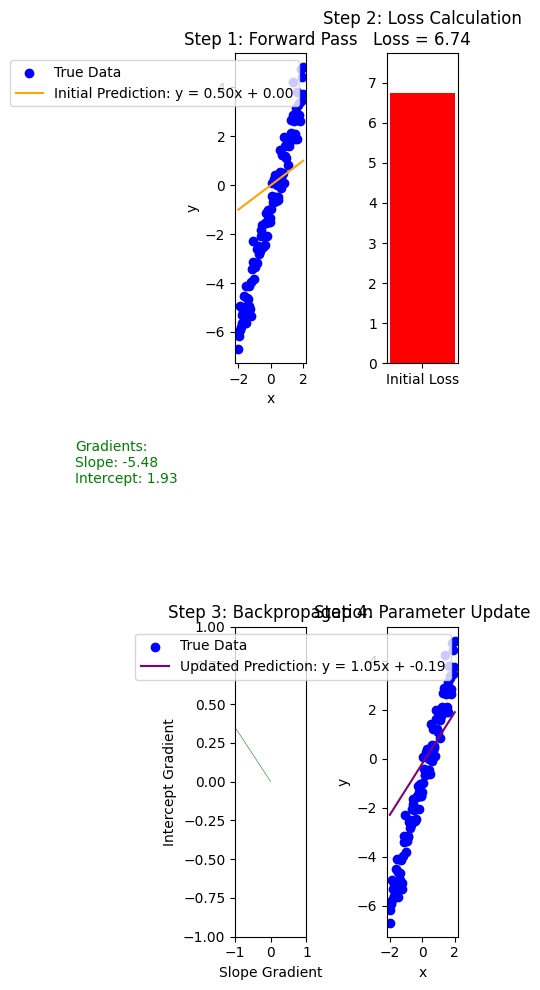

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Generating synthetic data to visualize forward pass, loss calculation, backpropagation, and parameter update
x = np.linspace(-2, 2, 100)
true_slope, true_intercept = 2.5, -1.0  # True relationship y = 2.5x - 1
y_true = true_slope * x + true_intercept + np.random.normal(0, 0.5, x.shape)  # Adding noise

# Starting parameters for a simple linear model
initial_slope, initial_intercept = 0.5, 0.0
learning_rate = 0.1

# Step 1: Forward Pass (initial prediction)
y_pred_initial = initial_slope * x + initial_intercept

# Step 2: Loss Calculation (Mean Squared Error)
loss_initial = np.mean((y_pred_initial - y_true) ** 2)

# Step 3: Backpropagation (gradient calculation)
grad_slope = 2 * np.mean((y_pred_initial - y_true) * x)
grad_intercept = 2 * np.mean(y_pred_initial - y_true)

# Step 4: Parameter Update (using SGD for one step)
updated_slope = initial_slope - learning_rate * grad_slope
updated_intercept = initial_intercept - learning_rate * grad_intercept
y_pred_updated = updated_slope * x + updated_intercept
loss_updated = np.mean((y_pred_updated - y_true) ** 2)

# Plotting each step
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Forward Pass
axs[0, 0].scatter(x, y_true, color='blue', label='True Data')
axs[0, 0].plot(x, y_pred_initial, color='orange', label=f'Initial Prediction: y = {initial_slope:.2f}x + {initial_intercept:.2f}')
axs[0, 0].set_title('Step 1: Forward Pass')
axs[0, 0].legend()
axs[0, 0].set_xlabel("x")
axs[0, 0].set_ylabel("y")

# Plot 2: Loss Calculation
axs[0, 1].bar(['Initial Loss'], [loss_initial], color='red')
axs[0, 1].set_title(f'Step 2: Loss Calculation\nLoss = {loss_initial:.2f}')
axs[0, 1].set_ylim(0, max(loss_initial, loss_updated) + 1)

# Plot 3: Backpropagation (Visualizing Gradients)
axs[1, 0].quiver(0, 0, grad_slope, grad_intercept, angles='xy', scale_units='xy', scale=1, color='green')
axs[1, 0].text(grad_slope, grad_intercept, f'Gradients:\nSlope: {grad_slope:.2f}\nIntercept: {grad_intercept:.2f}', color='green')
axs[1, 0].set_xlim(-1, 1)
axs[1, 0].set_ylim(-1, 1)
axs[1, 0].set_title('Step 3: Backpropagation')
axs[1, 0].set_xlabel('Slope Gradient')
axs[1, 0].set_ylabel('Intercept Gradient')

# Plot 4: Parameter Update
axs[1, 1].scatter(x, y_true, color='blue', label='True Data')
axs[1, 1].plot(x, y_pred_updated, color='purple', label=f'Updated Prediction: y = {updated_slope:.2f}x + {updated_intercept:.2f}')
axs[1, 1].set_title('Step 4: Parameter Update')
axs[1, 1].legend()
axs[1, 1].set_xlabel("x")
axs[1, 1].set_ylabel("y")

plt.tight_layout()
plt.show()
